# Custom Dropout Layer - MCAlphaDropout

## Concepts Covered
**MCAlphaDropout:** Custom dropout inspired by AlphaDropout.

 **MaxNormDense**: Dense layer with maximum weight norm constraint.

 Fashion-MNIST training and performance visualization.



# SetUp

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Custom Dropout Layer

In [12]:
class MCAlphaDropout(layers.Layer):
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=False):
        if training:
            keep_prob = 1.0 - self.rate
            noise_shape = tf.shape(inputs)
            random_tensor = keep_prob + tf.random.uniform(noise_shape, dtype=inputs.dtype)
            binary_tensor = tf.floor(random_tensor)
            return inputs / keep_prob * binary_tensor
        return inputs

# # Load and normalize Dataset

In [13]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# Model with MCAlphaDropout

In [14]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    MCAlphaDropout(0.3),
    layers.Dense(128, activation='relu'),
    MCAlphaDropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Custom MaxNormDense Layer

In [15]:
class MaxNormDense(layers.Layer):
    def __init__(self, units, max_norm=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.max_norm = max_norm

    def build(self, input_shape):
        self.kernel = self.add_weight(
            shape=(int(input_shape[-1]), self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="kernel"
        )
        self.bias = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

    def call(self, inputs):
        clipped_kernel = tf.clip_by_norm(self.kernel, self.max_norm, axes=[0])
        return tf.matmul(inputs, clipped_kernel) + self.bias

# Custom MCAlphaDropout Layer

In [16]:
class MCAlphaDropout(layers.Layer):
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=False):
        if training:
            keep_prob = 1.0 - self.rate
            noise_shape = tf.shape(inputs)
            random_tensor = keep_prob + tf.random.uniform(noise_shape, dtype=inputs.dtype)
            binary_tensor = tf.floor(random_tensor)
            outputs = inputs / keep_prob * binary_tensor
            return outputs
        return inputs

# Build Model

In [17]:
def build_custom_model():
    model = keras.models.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        MaxNormDense(256, max_norm=2.0),
        layers.Activation("relu"),
        MCAlphaDropout(0.3),
        MaxNormDense(128, max_norm=2.0),
        layers.Activation("relu"),
        MCAlphaDropout(0.3),
        layers.Dense(10, activation="softmax")
    ])
    return model

# Train and evaluate

In [18]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test), verbose=2)

Epoch 1/5
938/938 - 8s - 8ms/step - accuracy: 0.7911 - loss: 0.5847 - val_accuracy: 0.8418 - val_loss: 0.4344
Epoch 2/5
938/938 - 10s - 11ms/step - accuracy: 0.8435 - loss: 0.4304 - val_accuracy: 0.8584 - val_loss: 0.3929
Epoch 3/5
938/938 - 7s - 7ms/step - accuracy: 0.8562 - loss: 0.3944 - val_accuracy: 0.8616 - val_loss: 0.3779
Epoch 4/5
938/938 - 10s - 11ms/step - accuracy: 0.8647 - loss: 0.3702 - val_accuracy: 0.8660 - val_loss: 0.3674
Epoch 5/5
938/938 - 9s - 10ms/step - accuracy: 0.8706 - loss: 0.3547 - val_accuracy: 0.8727 - val_loss: 0.3526


# Plot training results

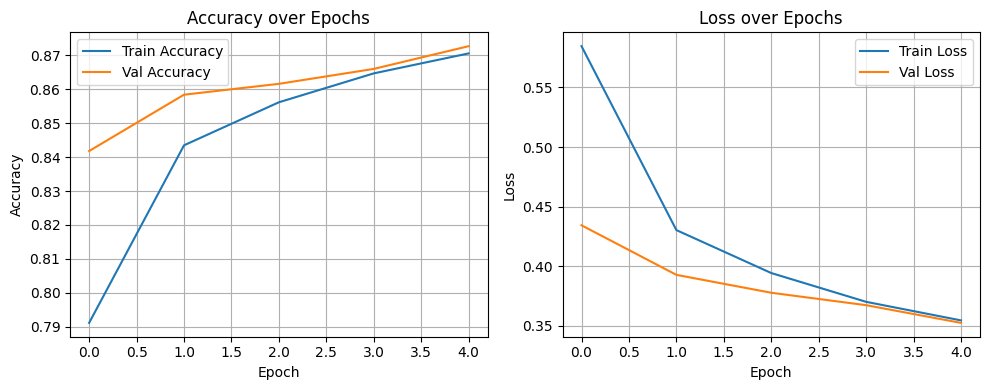

✅ MCAlphaDropout custom layer training complete.


In [19]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("✅ MCAlphaDropout custom layer training complete.")